In [1]:
#testing the ODEsolving etc.

In [22]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt
import itertools
import time

In [23]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')
KPB25L_df = all_df[all_df['Cell_Line']=="KPB25L"]

In [24]:
KPB25L_df 

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,GSM3554695,KPB25L
5,SRX5100690,0.002253,0.000725,0.000024,0.000245,antiPD1; antiCTLA4;,day7,day7,GSM3554696,KPB25L
6,SRX5100691,0.003449,0.000867,0.000003,0.000401,antiPD1; antiCTLA4;,day7,day7,GSM3554697,KPB25L
7,SRX5100680,0.004349,0.000949,0.000017,0.000510,antiPD1; antiCTLA4;,day7,day7,GSM3554698,KPB25L
8,SRX5100597,0.002915,0.000706,0.000000,0.000280,no_treatment,end,end,GSM3554699,KPB25L
9,SRX5100596,0.003232,0.001002,0.000000,0.000360,no_treatment,day3,day3,GSM3554700,KPB25L



Number of replicates 14
Dendritic_quanTIseq    0.002804
NK_quanTIseq           0.000678
T.CD8_quanTIseq        0.000026
Tregs_quanTIseq        0.000400
dtype: float64
<class 'pandas.Series'>
0.003906840157

Number of replicates 8
Dendritic_quanTIseq    0.003106
NK_quanTIseq           0.001042
T.CD8_quanTIseq        0.000034
Tregs_quanTIseq        0.000404
dtype: float64
<class 'pandas.Series'>
0.00458565151

Number of replicates 12
Dendritic_quanTIseq    0.002381
NK_quanTIseq           0.000601
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.000267
dtype: float64
<class 'pandas.Series'>
0.0032495509600000004

Number of replicates 9
Dendritic_quanTIseq    0.002851
NK_quanTIseq           0.000621
T.CD8_quanTIseq        0.000159
Tregs_quanTIseq        0.000446
dtype: float64
<class 'pandas.Series'>
0.00407721598

Number of replicates 4
Dendritic_quanTIseq    0.003542
NK_quanTIseq           0.000872
T.CD8_quanTIseq        0.000126
Tregs_quanTIseq        0.000595
dtype: float64
<c

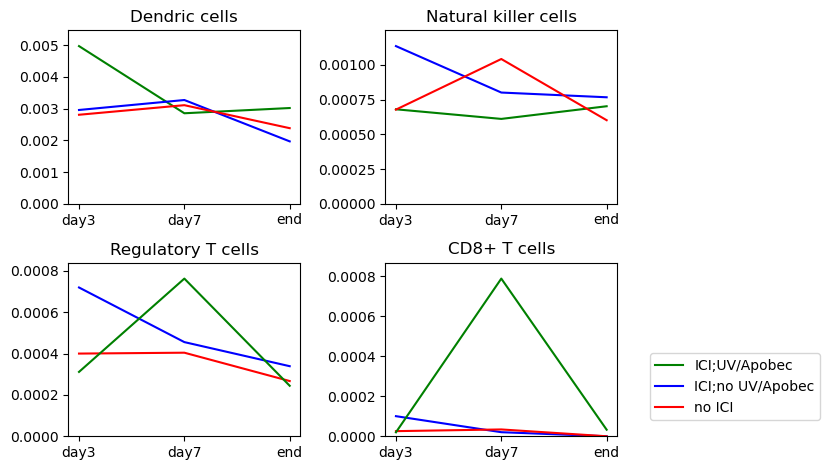

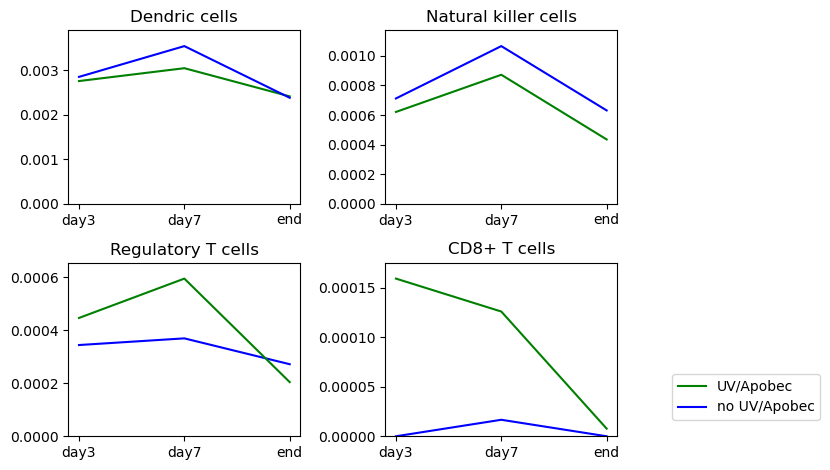

In [25]:


treatment_df = KPB25L_df[KPB25L_df['Mouse_treatment']!="no_treatment"]
no_treatment_df = KPB25L_df[KPB25L_df['Mouse_treatment']=="no_treatment"]

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

time_points = ["day3","day7","end"]

# no treatment (mutagen and no mutagen together)
no_treatment_Ds = []
no_treatment_NKs = []
no_treatment_T8s = []
no_treatment_Tregs = []

scatter_no_treatment_Ds = []
scatter_no_treatment_NKs = []
scatter_no_treatment_Tregs = []
scatter_no_treatment_T8s = []
scatter_no_treatment_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'].str.contains(day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_NKs.append(averages["NK_quanTIseq"])
    no_treatment_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_total = sum(averages)
    print(no_treatment_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_Ds.append(i)
                scatter_no_treatment_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_T8s.append(i)
no_treatment_mutagen_Ds = []
no_treatment_mutagen_NKs = []
no_treatment_mutagen_T8s = []
no_treatment_mutagen_Tregs = []

scatter_no_treatment_mutagen_Ds = []
scatter_no_treatment_mutagen_NKs = []
scatter_no_treatment_mutagen_Tregs = []
scatter_no_treatment_mutagen_T8s = []
scatter_no_treatment_mutagen_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'].str.contains("_"+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_treatment_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_mutagen_total = sum(averages)
    print(no_treatment_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_mutagen_Ds.append(i)
                scatter_no_treatment_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_mutagen_T8s.append(i)


no_treatment_no_mutagen_Ds = []
no_treatment_no_mutagen_NKs = []
no_treatment_no_mutagen_T8s = []
no_treatment_no_mutagen_Tregs = []

scatter_no_treatment_no_mutagen_Ds = []
scatter_no_treatment_no_mutagen_NKs = []
scatter_no_treatment_no_mutagen_Tregs = []
scatter_no_treatment_no_mutagen_T8s = []
scatter_no_treatment_no_mutagen_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition']==day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_no_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_no_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_treatment_no_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_no_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_no_mutagen_total = sum(averages)
    print(no_treatment_no_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_no_mutagen_Ds.append(i)
                scatter_no_treatment_no_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_no_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_no_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_no_mutagen_T8s.append(i)
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []
for day in time_points:
    day_df = treatment_df[treatment_df['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    print(mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


#treatment with mutagen
no_mutagen_Ds = []
no_mutagen_NKs = []
no_mutagen_T8s = []
no_mutagen_Tregs = []
scatter_no_mutagen_Ds = []
scatter_no_mutagen_NKs = []
scatter_no_mutagen_Tregs = []
scatter_no_mutagen_T8s = []
scatter_no_mutagen_times = []

for day in time_points:
    day_df = treatment_df[treatment_df['Condition']==day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_mutagen_total = sum(averages)
    print(no_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_mutagen_Ds.append(i)
                scatter_no_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_mutagen_T8s.append(i)


fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,no_mutagen_Ds,'g',label='ICI;UV/Apobec')
Dplot.plot(time_points,mutagen_Ds,'b',label='ICI;no UV/Apobec')

Dplot.plot(time_points,no_treatment_Ds,'r',label='no ICI')
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*no_mutagen_Ds,*mutagen_Ds,*no_treatment_Ds])*1.1)
handles,labels = Dplot.get_legend_handles_labels()
NKplot = ax[0,1]
NKplot.plot(time_points,no_mutagen_NKs,'b')
NKplot.plot(time_points,mutagen_NKs,'g')
NKplot.plot(time_points,no_treatment_NKs,'r')
NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*no_mutagen_NKs,*mutagen_NKs,*no_treatment_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,no_mutagen_Tregs,'b')
Tregplot.plot(time_points,no_treatment_Tregs,'r')
Tregplot.plot(time_points,mutagen_Tregs,'g')

Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*no_mutagen_Tregs,*mutagen_Tregs,*no_treatment_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,no_mutagen_T8s,'b')
T8plot.plot(time_points,no_treatment_T8s,'r')
T8plot.plot(time_points,mutagen_T8s,'g')

T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*no_mutagen_T8s,*mutagen_T8s,*no_treatment_T8s])*1.1)

fig.legend(handles,labels,bbox_to_anchor=(0.3, 0.1,1,1),loc = 'lower right')
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,no_treatment_no_mutagen_Ds,'g',label='UV/Apobec')
Dplot.plot(time_points,no_treatment_mutagen_Ds,'b',label='no UV/Apobec')

Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*no_treatment_no_mutagen_Ds,*no_treatment_mutagen_Ds])*1.1)
handles,labels = Dplot.get_legend_handles_labels()
NKplot = ax[0,1]
NKplot.plot(time_points,no_treatment_no_mutagen_NKs,'b')
NKplot.plot(time_points,no_treatment_mutagen_NKs,'g')

NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*no_treatment_no_mutagen_NKs,*no_treatment_mutagen_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,no_treatment_no_mutagen_Tregs,'b')
Tregplot.plot(time_points,no_treatment_mutagen_Tregs,'g')

Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*no_treatment_no_mutagen_Tregs,*no_treatment_mutagen_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,no_treatment_no_mutagen_T8s,'b')
T8plot.plot(time_points,no_treatment_mutagen_T8s,'g')

T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*no_treatment_no_mutagen_T8s,*no_treatment_mutagen_T8s])*1.1)

fig.legend(handles,labels,bbox_to_anchor=(0.3, 0.1,1,1),loc = 'lower right')
plt.tight_layout()
plt.show()

In [26]:
import math

In [27]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    ) 
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.17,#0.17,
          'lambda_DC_comb':8e-5,
          # 'D_0':2e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4,
          'C_init':0.8,
          'D_init':0.0,
          'N_init':0.0,
          'Tr_init':0.0,
          'T8_init':0.0}
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
# D_0            = params['D_0']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
# Tr_0       = params['Tr_0']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
# T8_0       = params['T8_0']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = params['C_init']
D_init     = params['D_init']
N_init     = params['N_init']
Tr_init    = params['Tr_init']
T8_init    = params['T8_init']
# eta_N = 300
# eta_8 = 328.2
# lambda_C = 1*lambda_C
# d_Tr = 1*d_Tr
# sigma_N = 2*sigma_N
# lambda_Tr = 2*lambda_Tr
# lamba_T8 = 2*lambda_T8
orig_params = params


def mean_square_error(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5
        
        error+=(y[0,0]-objective_function_day3['C'])**2
        error+=(y[0,1]-objective_function_day7['C'])**2
    else:
        N = 2*4
    error+=(y[1,0]-objective_function_day3['Ds'])**2
    error+=(y[1,1]-objective_function_day7['Ds'])**2
    error+=(y[2,0]-objective_function_day3['NKs'])**2
    error+=(y[2,1]-objective_function_day7['NKs'])**2
    error+=(y[3,0]-objective_function_day3['Tregs'])**2
    error+=(y[3,1]-objective_function_day7['Tregs'])**2
    error+=(y[4,0]-objective_function_day3['T8s'])**2
    error+=(y[4,1]-objective_function_day7['T8s'])**2
    return math.sqrt(error/N)

def mean_square_error_rel(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

def mean_square_error_rel(pred, true):
    return np.sqrt(np.mean(np.square(np.divide((pred - true),(pred)))))
def max_error_rel(pred, true):
    return np.sqrt(np.max(np.absolute(np.divide((pred - true),(pred)))))

In [28]:
# fitting UV treatment

In [29]:
objective_function_day3 = {'Ds':mutagen_Ds[0],
                          'NKs':mutagen_NKs[0],
                          'Tregs':mutagen_Tregs[0],
                          'T8s':mutagen_T8s[0]}
objective_function_day7 = {'Ds':mutagen_Ds[1],
                          'NKs':mutagen_NKs[1],
                          'Tregs':mutagen_Tregs[1],
                          'T8s':mutagen_T8s[1]}

true_mutagen = np.array([mutagen_Ds[:2],mutagen_NKs[:2],mutagen_Tregs[:2],mutagen_T8s[:2]])

In [30]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,5e-4],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,5e-4],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial parameter screen
params_to_change = {'lambda_T8_comb':[1e-5,5e-4,1e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[1e-5,5e-5,1e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.13,0.15,0.175,0.2,0.5]}
#narrowing down
params_to_change = {'lambda_T8_comb':[1e-5,3e-4,5e-4,1e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[1e-5,5e-5,1e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.13,0.15,0.175,0.2,0.5]}
# {'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.18, 'sigma_N': 0.0005, 'd_D': 0.1, 'K_Tr': 0.001, 'd_N': 0.5}
params_to_change = {'lambda_T8_comb':[1e-5,3e-4,5e-4,1e-4,2e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002,0.005,0.01],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,7e-4,1e-3],'d_T8': [0.01,0.075,0.1,0.18,0.2,0.25,0.5],'sigma_N':[5e-5,1e-4,2e-4,5e-4,7e-4,1e-3],'d_D':[0.01,0.05,0.1,0.2,1.0],'K_Tr': [2.25e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.15,0.175,0.2,0.5,0.75,1.0]}
# {'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.18, 'sigma_N': 0.0005, 'd_D': 0.1, 'K_Tr': 0.001, 'd_N': 0.5}
# {'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.1, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.005, 'd_N': 0.5} 0.37 error
# {'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} 0.366 error
params = orig_params.copy()

mean square rel error is 203.12245649456278
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
minimum maximum rel error is 23.9605033085921
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
mean square rel error is 103.51794434409186
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
minimum maximum rel error is 17.096569727416586
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
mean square rel error is 61.9126029045771
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.0001, 'd_N': 0.1}
minimum maximu

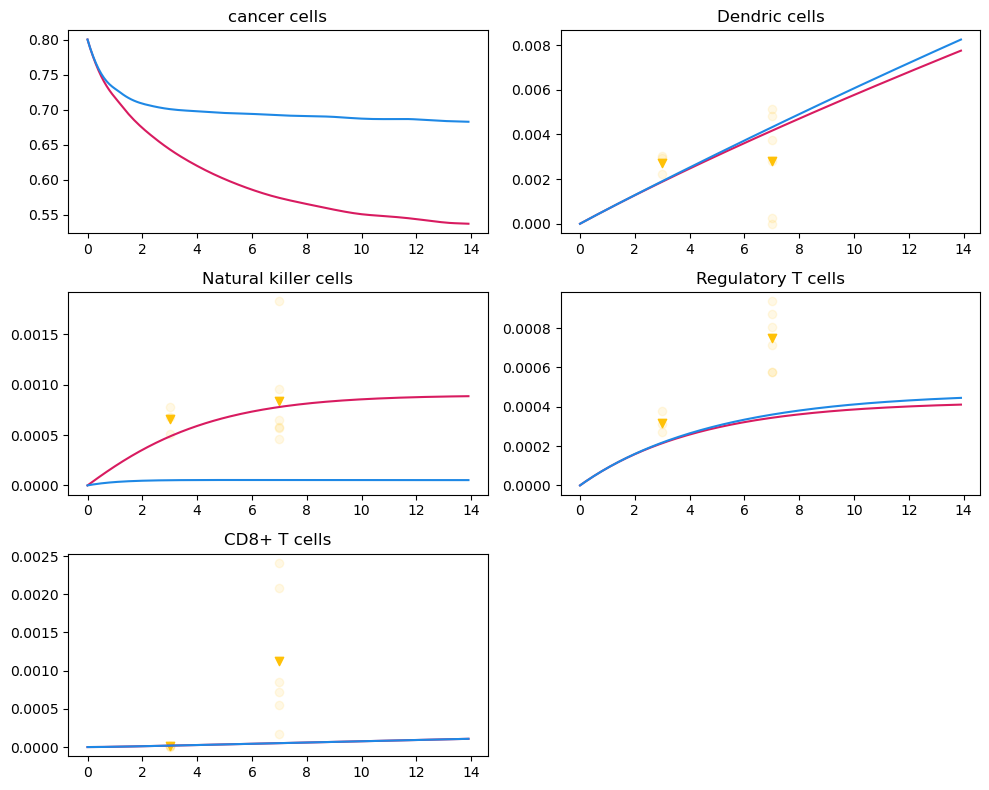

iteration 155580 of 2593080 i.e. 5.9998148919431715%
time : 255.1945297718048, time per iteration : 0.0016402785047679959
iteration 181510 of 2593080 i.e. 6.999784040600367%
time : 297.65140080451965, time per iteration : 0.0016398622709741593
mean square rel error is 6.989343747954186
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 4.394781581822458
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.832339852585733
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
minimum maximum rel error is 4.342712299606957
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_T

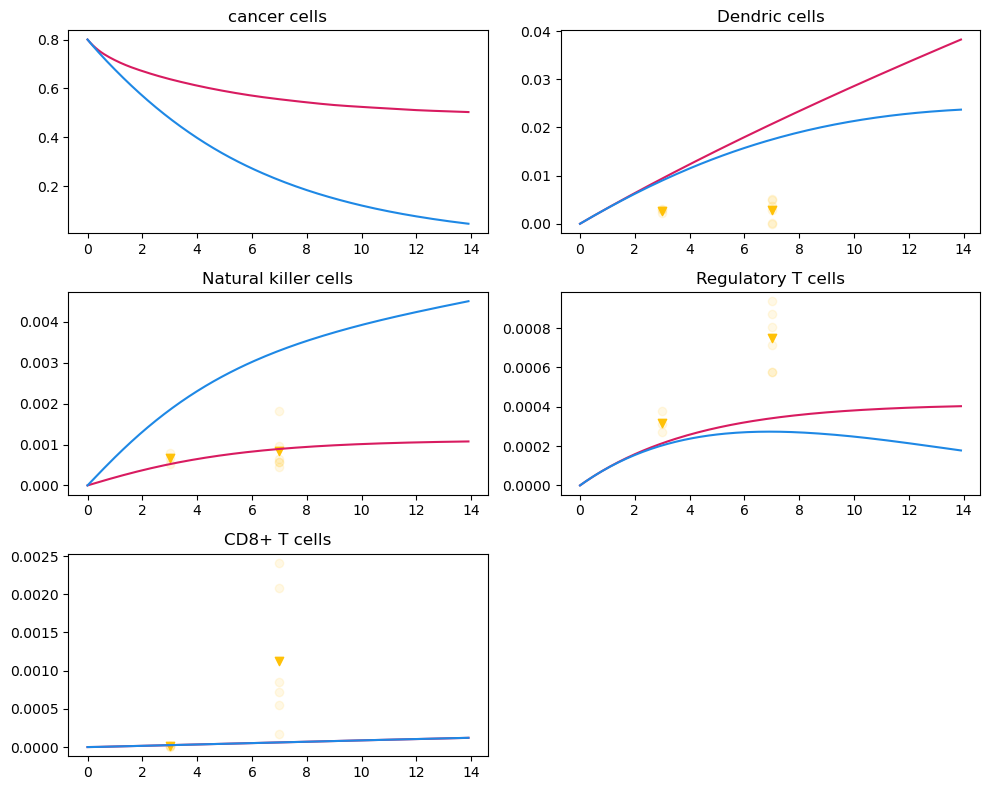

iteration 285230 of 2593080 i.e. 10.999660635229148%
time : 465.7083423137665, time per iteration : 0.0016327467037610577
minimum maximum rel error is 4.149295866723418
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.144184916191552
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
minimum maximum rel error is 4.10172648056323
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
mean square rel error is 6.139596122485342
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 0.0001, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.003273967425081
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_

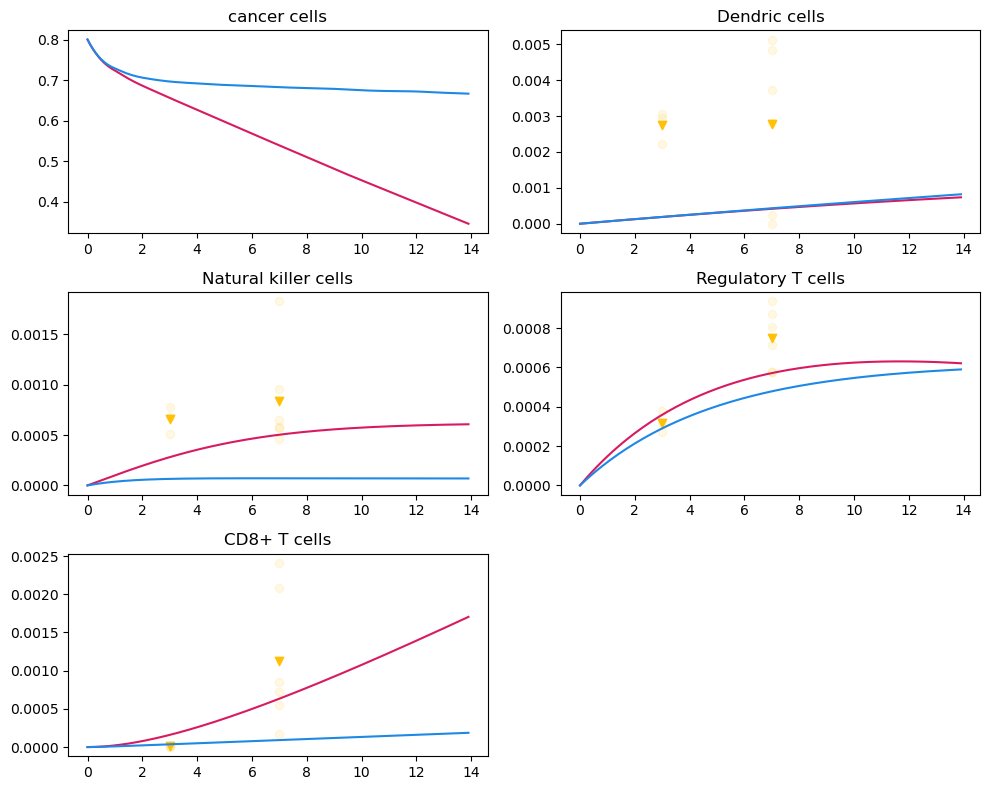

iteration 414880 of 2593080 i.e. 15.999506378515123%
time : 676.263580083847, time per iteration : 0.0016300221270821613
mean square rel error is 3.107818170221573
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
minimum maximum rel error is 2.733229787237277
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
mean square rel error is 2.0409003675306683
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
minimum maximum rel error is 1.869650353146547
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
mean square rel error is 1.758076606353245
{'lambda_T8_comb': 0.0003, 'lambda_DC_com

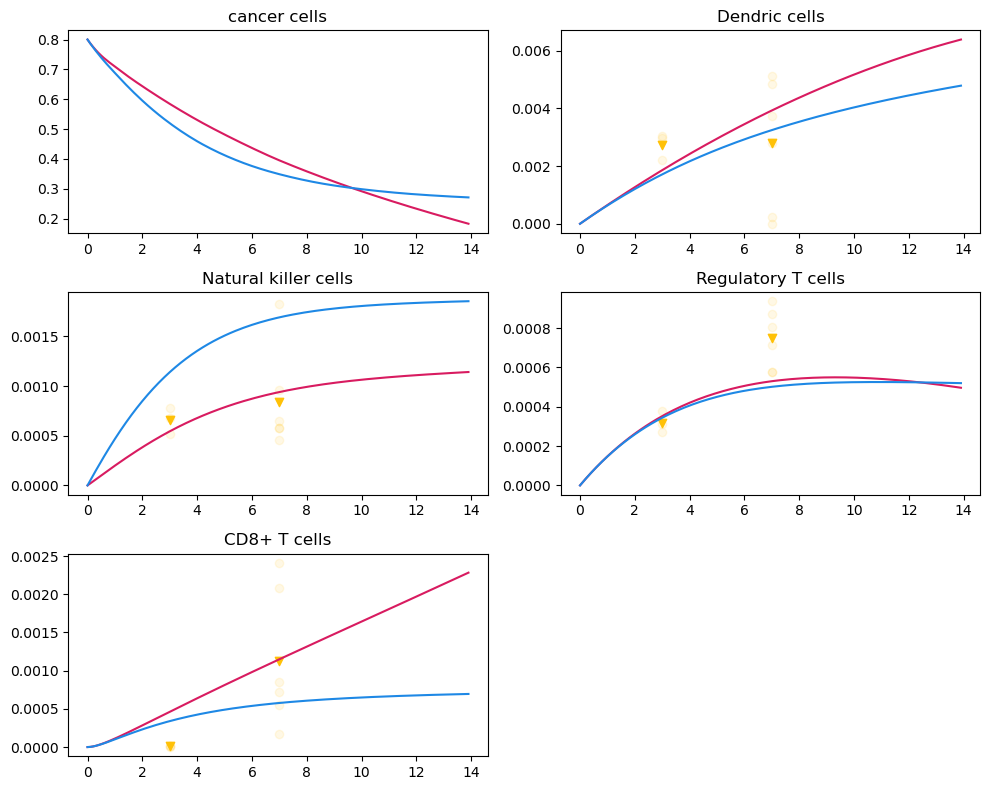

minimum maximum rel error is 0.9801052936233141
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.15}
minimum maximum rel error is 0.9801050608573951
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.175}
minimum maximum rel error is 0.9801048330565356
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.2}
minimum maximum rel error is 0.980103287056415
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.001, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.175}
minimum maximum rel error is 0.9801030345457518
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.001, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.2

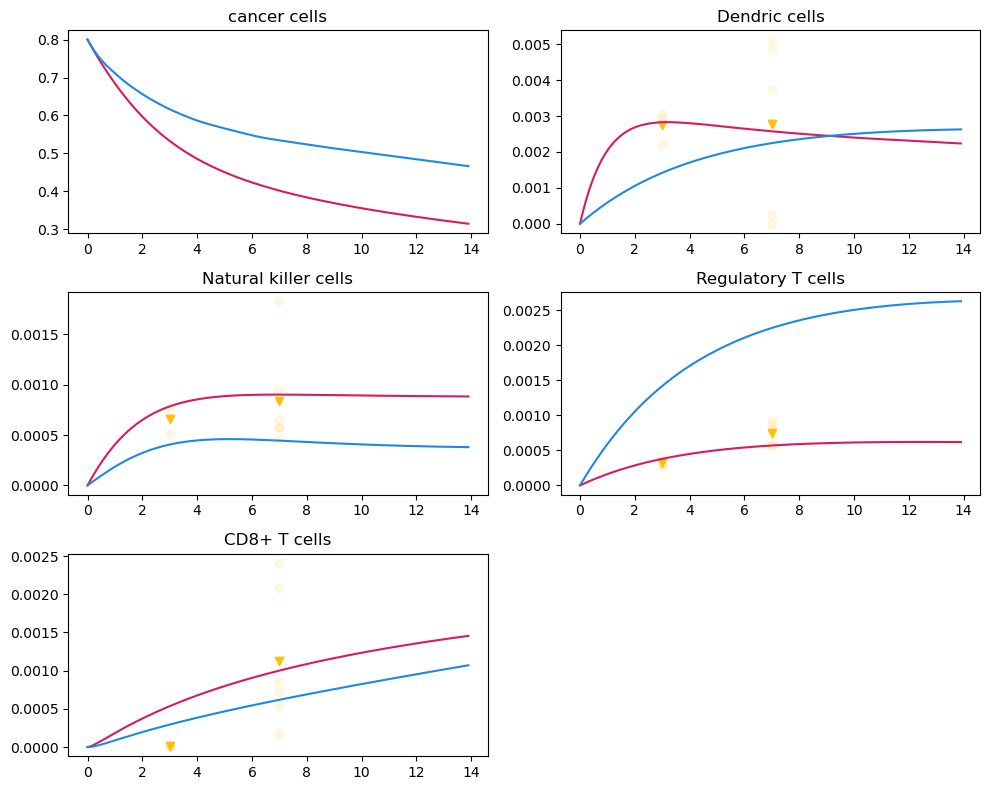

mean square rel error is 0.3741203389826386
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 1.0, 'K_Tr': 0.001, 'd_N': 0.1}
mean square rel error is 0.3708596829880828
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.001, 'd_N': 0.5}
mean square rel error is 0.3705615146051221
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.1, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.005, 'd_N': 0.5}
iteration 674180 of 2593080 i.e. 25.999197865087076%
time : 1111.0238716602325, time per iteration : 0.0016479632615328734
iteration 700110 of 2593080 i.e. 26.999167013744273%
time : 1154.2657976150513, time per iteration : 0.001648692059269331
iteration 726040 of 2593080 i.e. 27.999136162401467%
time : 1197.1605999469757, time per iteration : 0.001648890694654531
iteration 751970 of 2593080 i.e. 28.999105311058663%

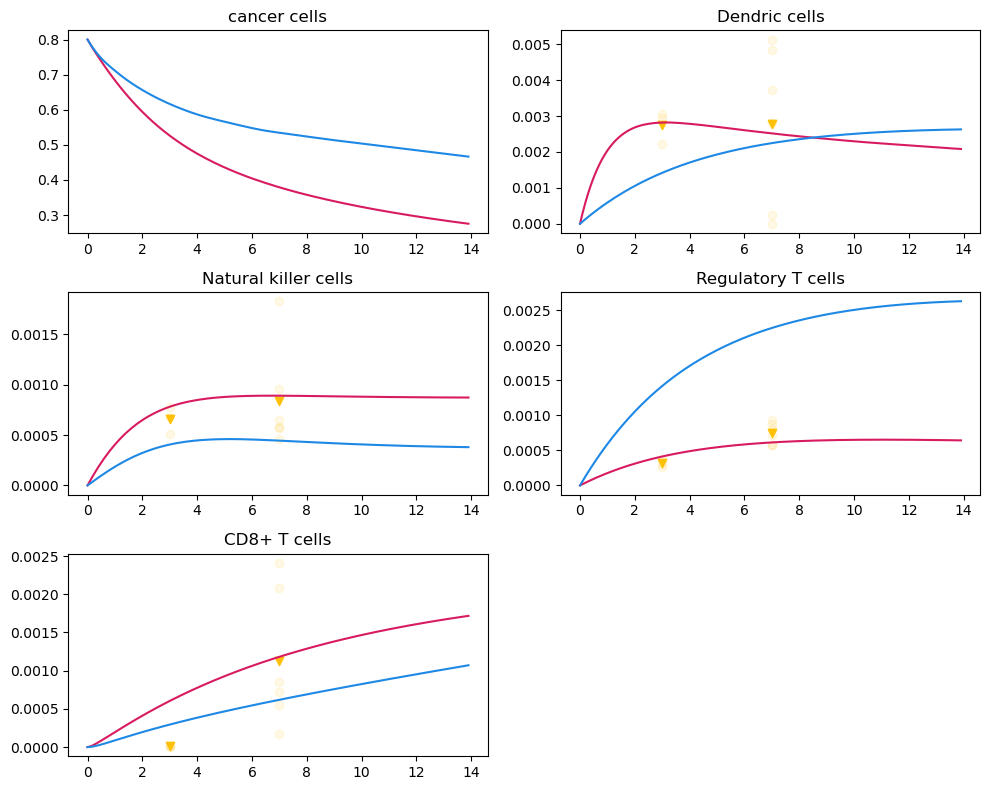

iteration 803830 of 2593080 i.e. 30.999043608373057%
time : 1326.0302040576935, time per iteration : 0.0016496401030786278
iteration 829760 of 2593080 i.e. 31.999012757030247%
time : 1368.751978635788, time per iteration : 0.0016495757552012485
iteration 855690 of 2593080 i.e. 32.998981905687444%
time : 1411.8181591033936, time per iteration : 0.0016499177962853294
iteration 881620 of 2593080 i.e. 33.99895105434464%
time : 1455.4180374145508, time per iteration : 0.001650845077714379
minimum maximum rel error is 0.9763379542239854
{'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.001, 'd_D': 0.01, 'K_Tr': 0.0001, 'd_N': 0.1}
iteration 907550 of 2593080 i.e. 34.99892020300184%
time : 1499.050613641739, time per iteration : 0.0016517554004096071


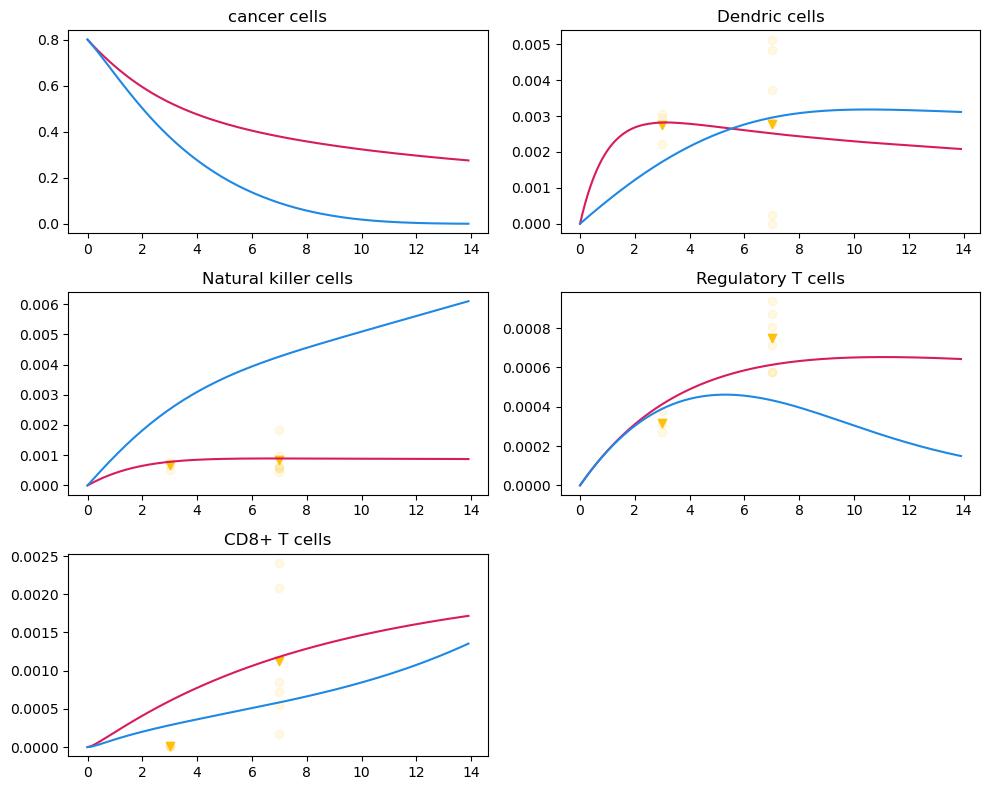

iteration 933480 of 2593080 i.e. 35.99888935165903%
time : 1544.0711607933044, time per iteration : 0.0016541020276741917
iteration 959410 of 2593080 i.e. 36.99885850031623%
time : 1588.1012029647827, time per iteration : 0.0016552893996985467
iteration 985340 of 2593080 i.e. 37.99882764897342%
time : 1632.7579145431519, time per iteration : 0.0016570502715236891
iteration 1011270 of 2593080 i.e. 38.99879679763062%
time : 1677.6227293014526, time per iteration : 0.0016589266262239091
iteration 1037200 of 2593080 i.e. 39.99876594628781%
time : 1722.1507976055145, time per iteration : 0.0016603844944133384


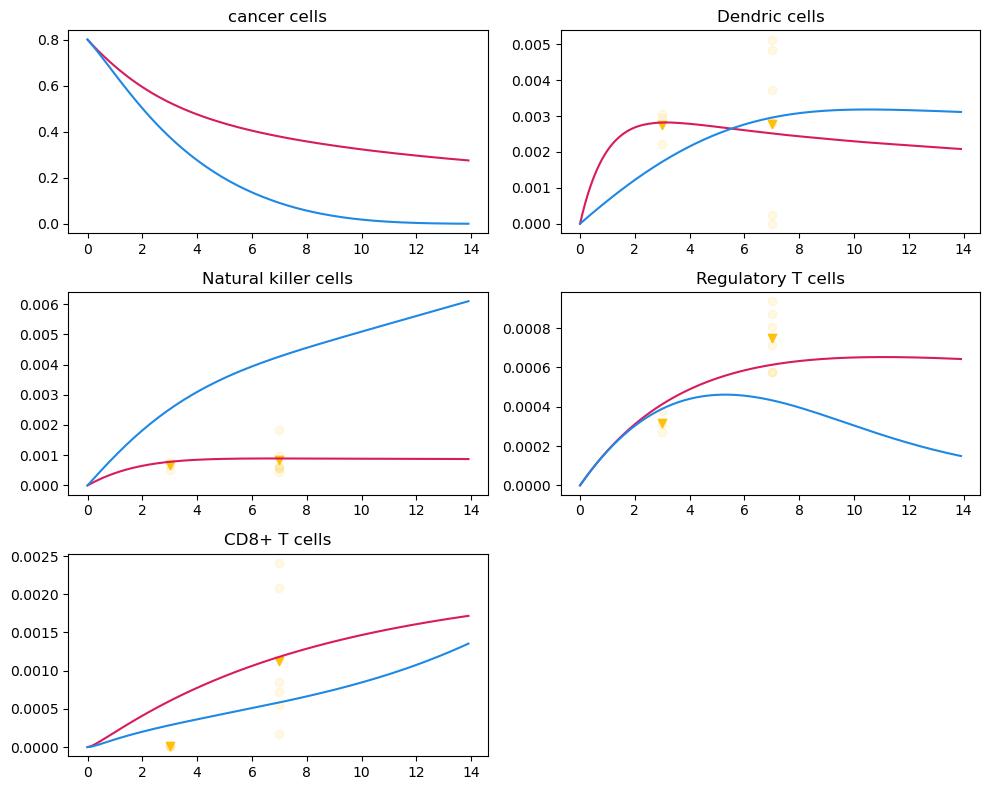

iteration 1063130 of 2593080 i.e. 40.99873509494501%
time : 1768.1223866939545, time per iteration : 0.0016631290497812633
iteration 1089060 of 2593080 i.e. 41.998704243602205%
time : 1813.1402320861816, time per iteration : 0.0016648671625862502
iteration 1114990 of 2593080 i.e. 42.9986733922594%
time : 1858.0705614089966, time per iteration : 0.0016664459424828892
iteration 1140920 of 2593080 i.e. 43.99864254091659%
time : 1899.3147010803223, time per iteration : 0.0016647220673494394
iteration 1166850 of 2593080 i.e. 44.998611689573785%
time : 1941.0899047851562, time per iteration : 0.0016635299351117593


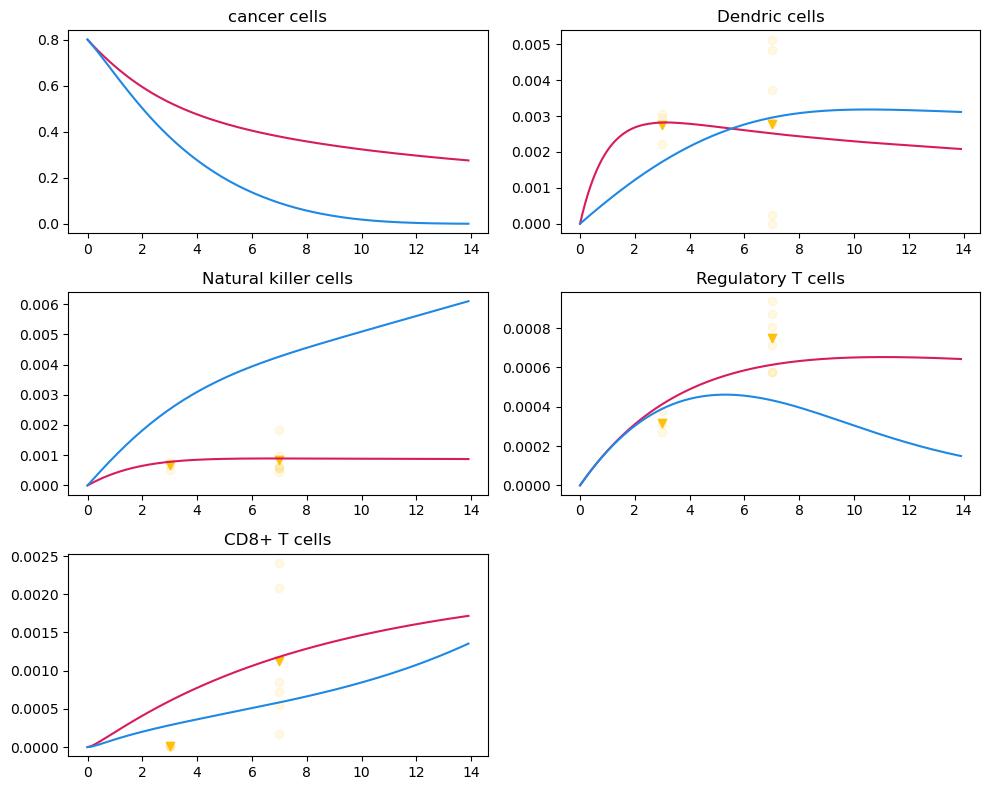

iteration 1192780 of 2593080 i.e. 45.998580838230986%
time : 1982.803221464157, time per iteration : 0.0016623377500160608
iteration 1218710 of 2593080 i.e. 46.99854998688818%
time : 2023.713783979416, time per iteration : 0.0016605376044993606
iteration 1244640 of 2593080 i.e. 47.99851913554537%
time : 2065.7722883224487, time per iteration : 0.001659734773366153
iteration 1270570 of 2593080 i.e. 48.998488284202566%
time : 2106.64896941185, time per iteration : 0.0016580345588293837
iteration 1296500 of 2593080 i.e. 49.998457432859766%
time : 2149.1191098690033, time per iteration : 0.0016576313998218305


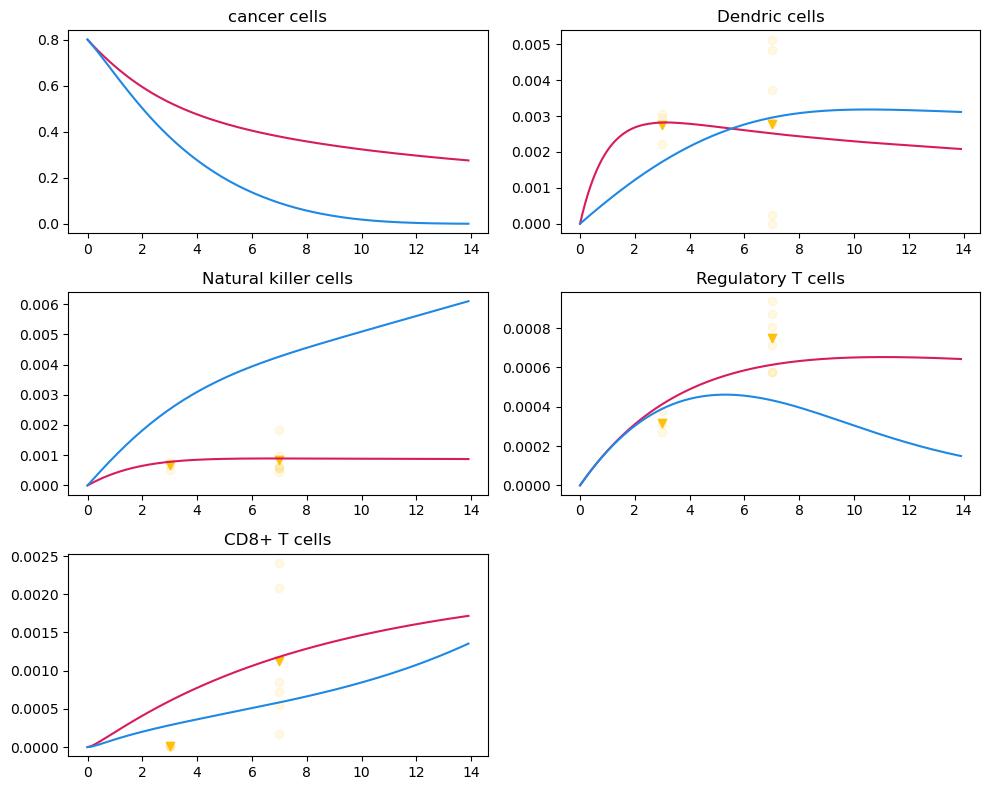

iteration 1322430 of 2593080 i.e. 50.998426581516966%
time : 2190.46937584877, time per iteration : 0.0016563972201543902
iteration 1348360 of 2593080 i.e. 51.99839573017415%
time : 2231.984310865402, time per iteration : 0.0016553326343598164
minimum maximum rel error is 0.9726599112064597
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9725969346122637
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.05, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9725162184970094
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.1, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9723481670668614
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, '

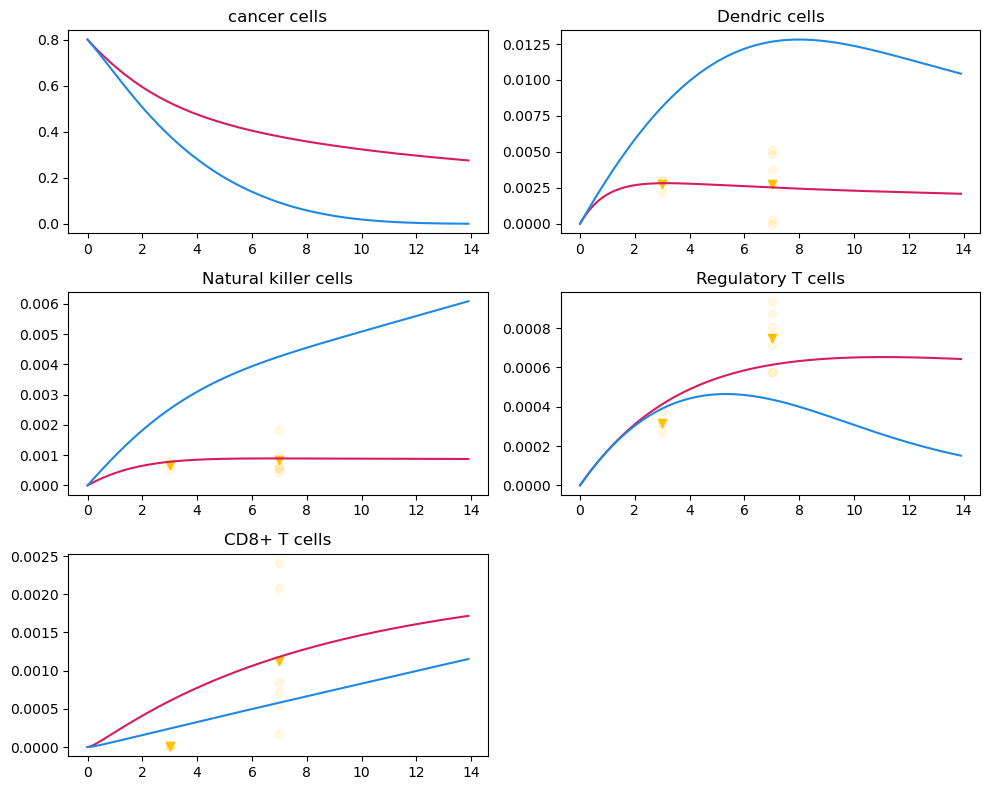

iteration 1452080 of 2593080 i.e. 55.99827232480293%
time : 2400.9537699222565, time per iteration : 0.0016534583286886787
iteration 1478010 of 2593080 i.e. 56.99824147346013%
time : 2444.1678369045258, time per iteration : 0.001653688295007832
iteration 1503940 of 2593080 i.e. 57.99821062211733%
time : 2486.191875219345, time per iteration : 0.0016531190574220682
iteration 1529870 of 2593080 i.e. 58.99817977077453%
time : 2528.2160425186157, time per iteration : 0.0016525692003363788
iteration 1555800 of 2593080 i.e. 59.99814891943171%
time : 2570.949330806732, time per iteration : 0.0016524934636886054


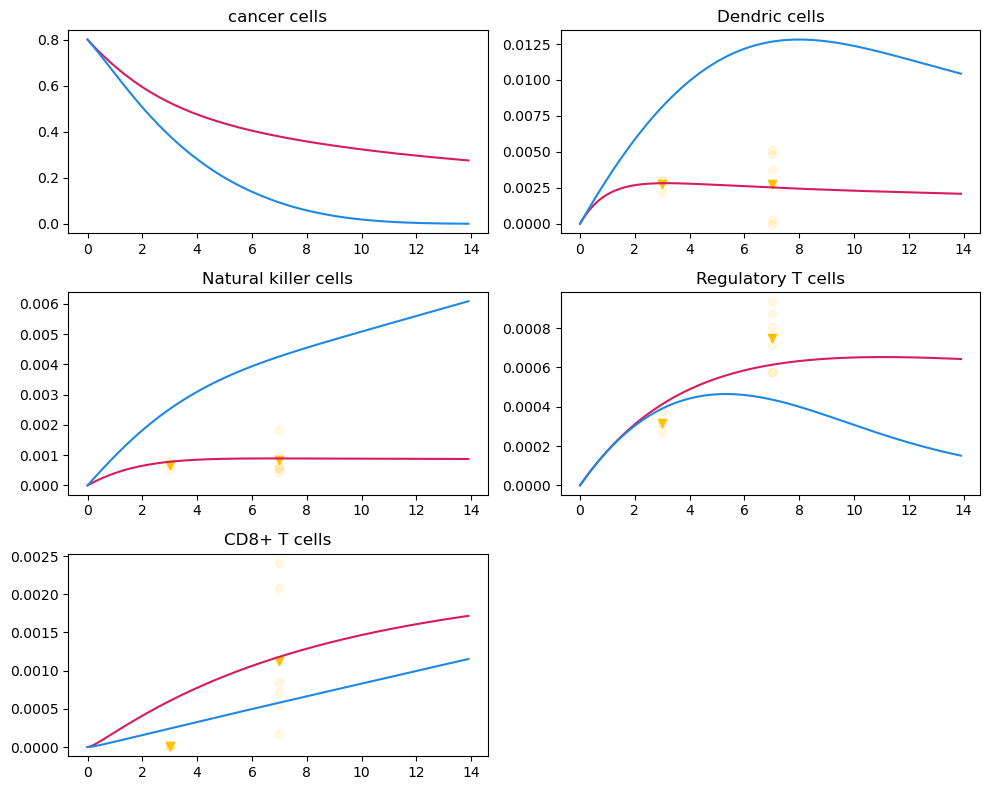

iteration 1581730 of 2593080 i.e. 60.998118068088914%
time : 2613.2504065036774, time per iteration : 0.0016521469571315441
iteration 1607660 of 2593080 i.e. 61.998087216746114%
time : 2656.4700944423676, time per iteration : 0.00165238302529289
iteration 1633590 of 2593080 i.e. 62.9980563654033%
time : 2698.345080137253, time per iteration : 0.001651788441492206
iteration 1659520 of 2593080 i.e. 63.998025514060494%
time : 2741.0073475837708, time per iteration : 0.0016516868417275903
iteration 1685450 of 2593080 i.e. 64.9979946627177%
time : 2784.5186154842377, time per iteration : 0.0016520920914202366


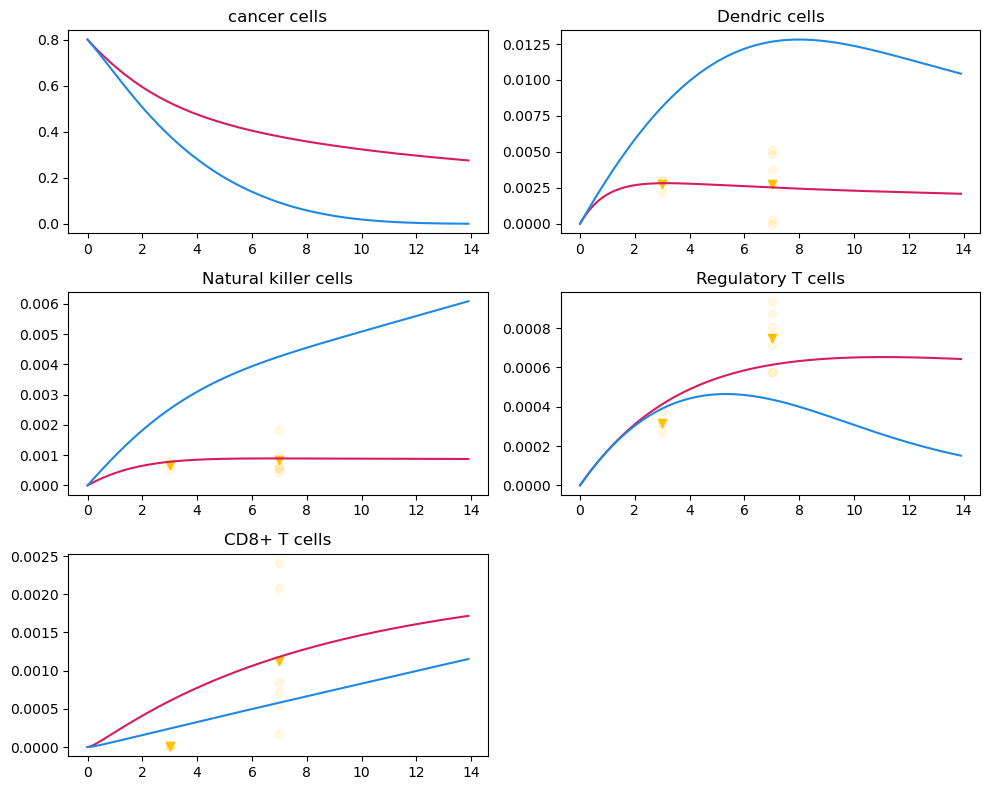

iteration 1711380 of 2593080 i.e. 65.99796381137489%
time : 2827.571954011917, time per iteration : 0.0016522174818052783
iteration 1737310 of 2593080 i.e. 66.99793296003207%
time : 2871.5848677158356, time per iteration : 0.00165289146307558
iteration 1763240 of 2593080 i.e. 67.99790210868927%
time : 2914.3143243789673, time per iteration : 0.0016528177244044867
mean square rel error is 0.37045245455759485
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 1.0, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 0.37023963532341525
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.1}
mean square rel error is 0.36653269985246495
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.005, 'd_N': 0.5}
mean square rel error is 0.36638441961183776
{'lam

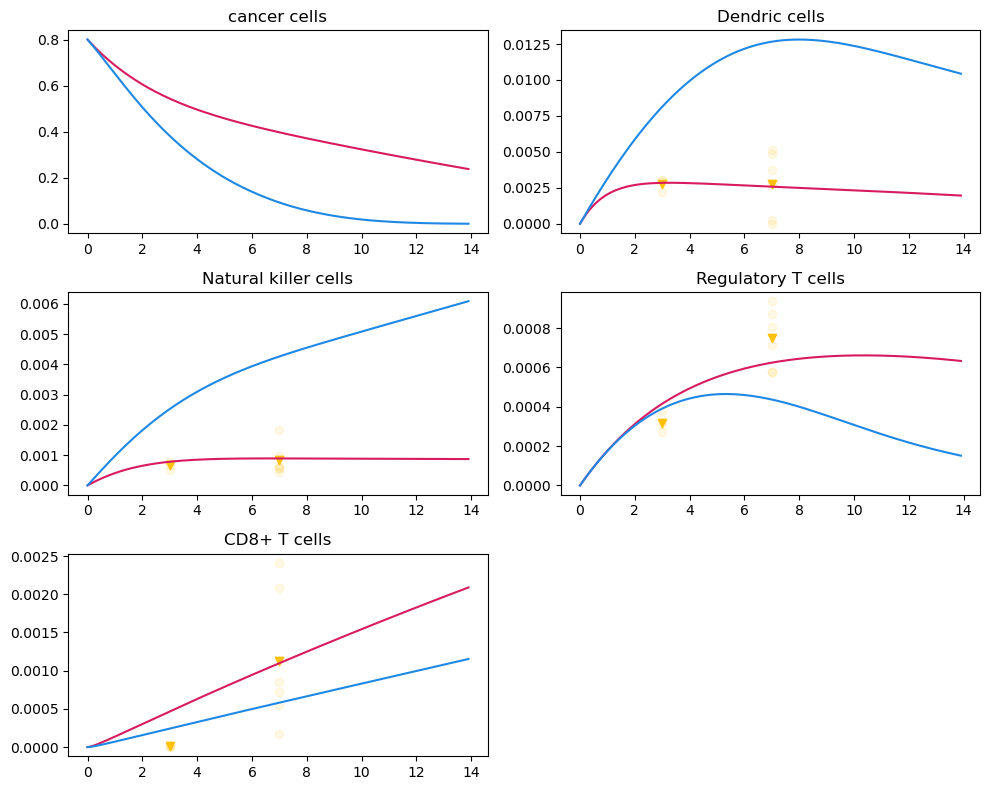

iteration 1841030 of 2593080 i.e. 70.99780955466086%
time : 3044.9541013240814, time per iteration : 0.0016539405122806697
iteration 1866960 of 2593080 i.e. 71.99777870331806%
time : 3087.836023569107, time per iteration : 0.0016539379652317709
iteration 1892890 of 2593080 i.e. 72.99774785197526%
time : 3129.816907644272, time per iteration : 0.0016534594760626723
iteration 1918820 of 2593080 i.e. 73.99771700063246%
time : 3173.1479890346527, time per iteration : 0.001653697579259468


In [ ]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000

prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
plot_points = np.arange(0,prod,prod//20,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    if iters in plot_points:
        c1 = (216/255,27/255,96/255)
        c2 = (30/255,136/255,229/255)
        c3 = (255/255,193/255,7/255)
        c4 = (0/255,77/255,64/255)
        
        tspan = (0.0,14.0,)
        C_init     = mutagen_best_params['C_init']
        D_init     = mutagen_best_params['D_init']
        N_init     = mutagen_best_params['N_init']
        Tr_init    = mutagen_best_params['Tr_init']
        T8_init    = mutagen_best_params['T8_init']
        C0 = [C_init,D_init,N_init,Tr_init,T8_init]
        sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
        sol_mm = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params_mm,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
        
        t = sol.t
        y = sol.y
        t_mm = sol_mm.t
        y_mm = sol_mm.y
        
        
        fig,ax = plt.subplots(3,2,figsize = (10,8))
        cancer = ax[0,0]
        cancer.plot(t,y[0],color = c1)
        cancer.plot(t,y_mm[0],color = c2)
    
        cancer.set_title('cancer cells')
        D_cells = ax[0,1]
        D_cells.plot(t,y[1],color = c1,label = 'mean square error')
        D_cells.plot(t,y_mm[1],color = c2,label = 'min max error ')
        D_cells.set_title('Dendric cells')
        D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
        D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)
        
        
        NK_cells = ax[1,0]
        NK_cells.plot(t,y[2],color = c1)
        NK_cells.plot(t,y_mm[2],color = c2)
        
        NK_cells.set_title('Natural killer cells')
        NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
        NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)
        
        
        Treg = ax[1,1]
        Treg.plot(t,y[3],color = c1)
        Treg.plot(t,y_mm[3],color = c2)
        
        Treg.set_title('Regulatory T cells')
        Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
        Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
        # {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
        T8 = ax[2,0]
        T8.plot(t,y[4],color = c1)
        T8.plot(t,y_mm[4],color = c2)
        
        T8.set_title('CD8+ T cells')
        T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
        T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)
        
        
        extra_plot = ax[2,1]
        extra_plot.set_visible(False)
        
        
        plt.tight_layout()
        plt.show()
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']
    

    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            mutagen_best_params = params.copy()
            print(f"mean square rel error is {distance}")
            print({k:mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:mutagen_best_params_mm[k] for k in params_to_change.keys()})
        
print(f'The minimum error is {minimum_distance}')
print({k:mutagen_best_params[k] for k in params_to_change.keys()})

In [31]:

mutagen_best_params = orig_params.copy()
mutagen_best_params.update({'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} )
print(mutagen_best_params)
print({k:mutagen_best_params[k] for k in params_to_change.keys()})
# mutagen_best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.15, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'lambda_T8_comb': 0.00125, 'K_Tr': 3e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.005, 'K_C': 0.4, 'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'lambda_T8_comb': 0.0002, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5}


/home/ploy/miniforge3/envs/MIB_ODEs/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


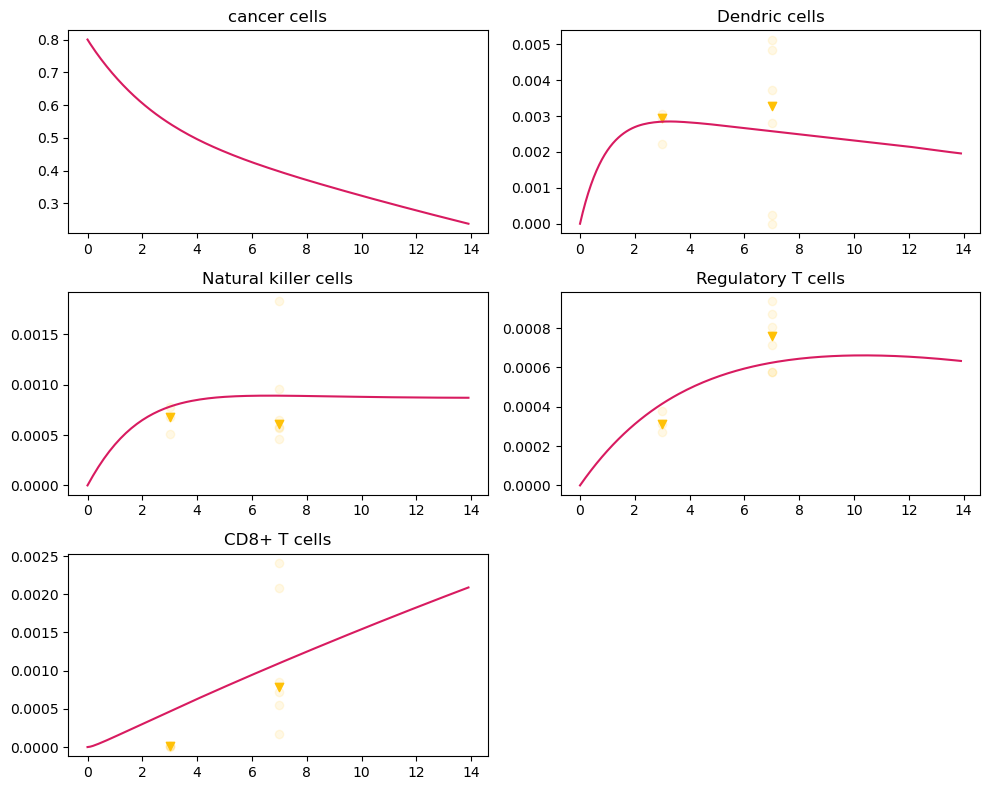

In [32]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = mutagen_best_params['C_init']
D_init     = mutagen_best_params['D_init']
N_init     = mutagen_best_params['N_init']
Tr_init    = mutagen_best_params['Tr_init']
T8_init    = mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [39]:
#Fitting non-mutagen treatment

In [33]:

true_no_mutagen = np.array([no_mutagen_Ds[:2],no_mutagen_NKs[:2],no_mutagen_Tregs[:2],no_mutagen_T8s[:2]])

In [57]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,9.5e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0025, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00035} error 0.5
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,7.5e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.125e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,3.75e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0025, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00035}
params_to_change = {'lambda_T8_comb':[5e-6,7.5e-6,1e-5,2.5e-6,5e-5,7.5e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.125e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,3.75e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 5e-05, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00025}
params = orig_params.copy()

In [58]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            no_mutagen_best_params = params.copy()
            print(distance)
            print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_mutagen_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})

9.776383742686582
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
minimum maximum rel error is 5.109221648046315
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
9.584919840647144
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
minimum maximum rel error is 5.109122163888044
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
9.540834066268195
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
minimum maximum rel error is 5.1090633440006945
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
9.522650488882428
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0001}
minimum maximum rel error is 5.109024472316502
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'la

KeyboardInterrupt: 

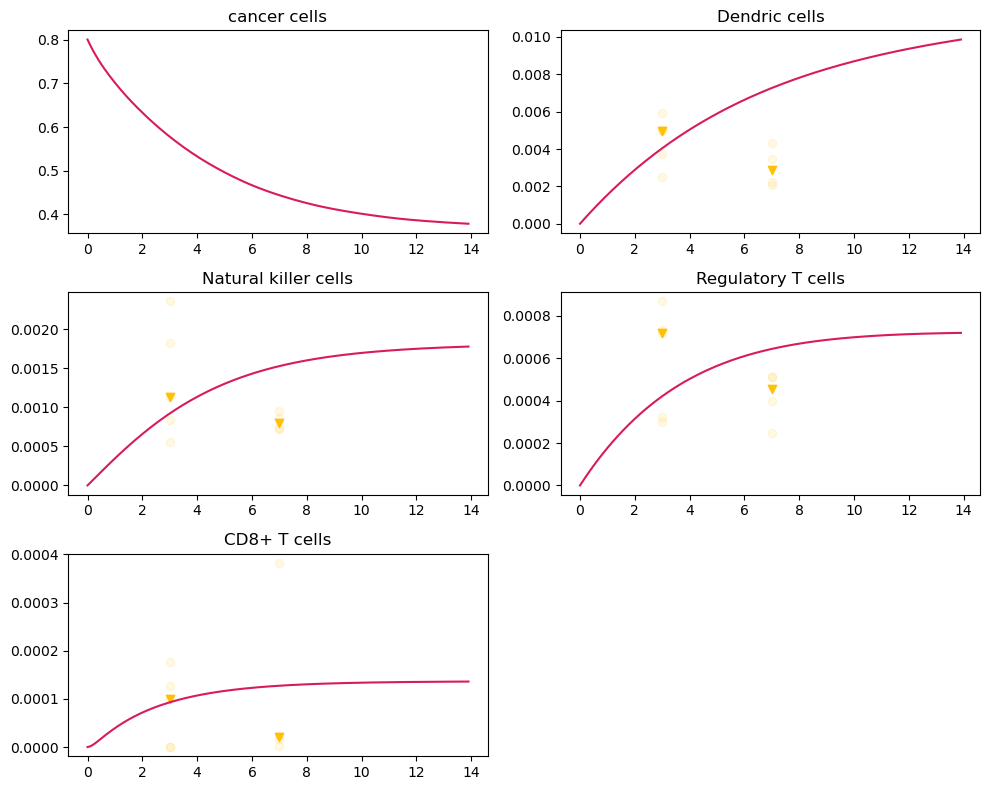

In [44]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_mutagen_best_params['C_init']
D_init     = no_mutagen_best_params['D_init']
N_init     = no_mutagen_best_params['N_init']
Tr_init    = no_mutagen_best_params['Tr_init']
T8_init    = no_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_mutagen_times,scatter_no_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [ ]:
#Fitting no treatment

In [48]:
# objective_function_day3 = {'Ds':no_treatment_Ds[0],
#                           'NKs':no_treatment_NKs[0],
#                           'Tregs':no_treatment_Tregs[0],|
#                           'T8s':no_treatment_T8s[0]}
# objective_function_day7 = {'Ds':no_treatment_Ds[1],
#                           'NKs':no_treatment_NKs[1],
#                           'Tregs':no_treatment_Tregs[1],
#                           'T8s':no_treatment_T8s[1]}
true_no_treatment = np.array([no_treatment_Ds[:2],no_treatment_NKs[:2],no_treatment_Tregs[:2],no_treatment_T8s[:2]])

In [54]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.000275, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr':[]}

params = orig_params.copy()

In [55]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_treatment)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_treatment)
        if minimum_distance>distance:
            minimum_distance = distance
            no_treatment_best_params = params.copy()
            print(distance)
            print({k:no_treatment_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_treatment_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_treatment_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_treatment_best_params[k] for k in params_to_change.keys()})

2.099480469172714
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
minimum maximum rel error is 1.9024548566621753
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
1.6707240310705078
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
minimum maximum rel error is 1.5690106034802183
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
1.563307603434878
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
minimum maximum rel error is 1.5689861427142822
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
1.518899463726497
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0001}
minimum maximum rel error is 1.5689699776802197
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005,

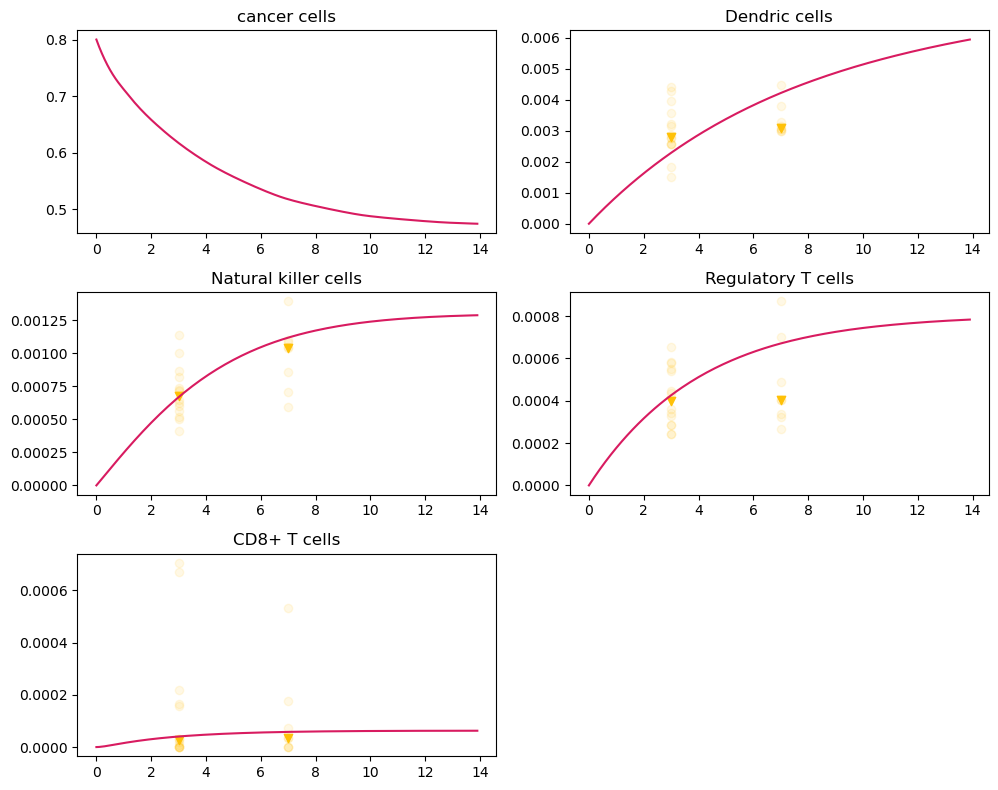

In [59]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_treatment_best_params['C_init']
D_init     = no_treatment_best_params['D_init']
N_init     = no_treatment_best_params['N_init']
Tr_init    = no_treatment_best_params['Tr_init']
T8_init    = no_treatment_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_treatment_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_treatment_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_treatment_times,scatter_no_treatment_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_treatment_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_treatment_times,scatter_no_treatment_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_treatment_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [91]:
# best_params.update({'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0013, 'd_T8': 1e-05, 'sigma_N': 0.00035, 'K_Tr': 2.25e-05, 'd_N': 0.22})

In [ ]:
mutagen_best_params = orig_params.copy()
mutagen_best_params.update({'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} )
no_mutagen_best_params = mutagen_best_params.copy()
no_mutagen_best_params.update({'lambda_T8_comb': 5e-05, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00025})
no_treatment_best_params = mutagen_best_params.copy()
no_treatment_best_params.update({'lambda_T8_comb': 5e-05, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00025})

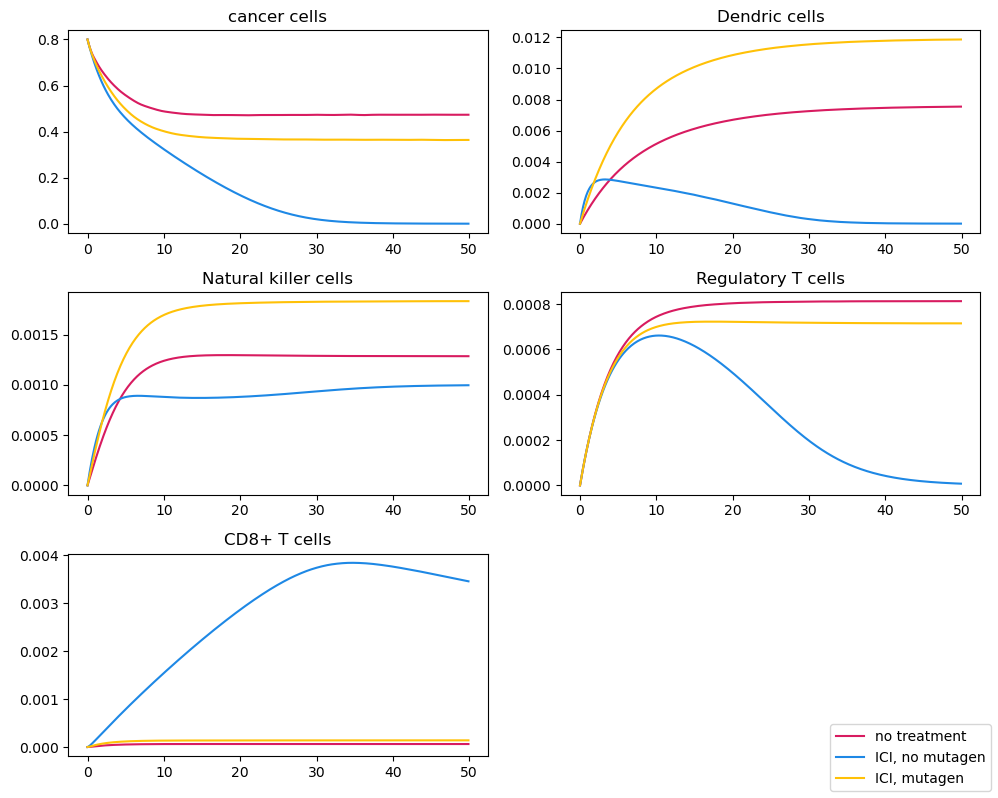

In [66]:

c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,50.0,)
C_init     = no_treatment_best_params['C_init']
D_init     = no_treatment_best_params['D_init']
N_init     = no_treatment_best_params['N_init']
Tr_init    = no_treatment_best_params['Tr_init']
T8_init    = no_treatment_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol_no_treatment = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))
sol_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))
sol_no_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))

t_no_treatment = sol_no_treatment.t
y_no_treatment = sol_no_treatment.y
t_no_mutagen = sol_no_mutagen.t
y_no_mutagen = sol_no_mutagen.y
t_mutagen = sol_mutagen.t
y_mutagen = sol_mutagen.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t_no_treatment,y_no_treatment[0],color = c1,label = 'no treatment')
cancer.plot(t_no_mutagen,y_no_mutagen[0],color = c2,label = 'ICI, no mutagen')
cancer.plot(t_mutagen,y_mutagen[0],color = c3,label = 'ICI, mutagen')
handles,labels = cancer.get_legend_handles_labels()

cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t_no_treatment,y_no_treatment[1],color = c1)
D_cells.plot(t_no_mutagen,y_no_mutagen[1],color = c2)
D_cells.plot(t_mutagen,y_mutagen[1],color = c3)


D_cells.set_title('Dendric cells')
# D_cells.scatter([3.0,7.0],no_treatment_Ds[:2],alpha=1.0,marker ='v',color = c3)
# D_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t_no_treatment,y_no_treatment[2],color = c1)
NK_cells.plot(t_no_mutagen,y_no_mutagen[2],color = c2)
NK_cells.plot(t_mutagen,y_mutagen[2],color = c3)

NK_cells.set_title('Natural killer cells')
# NK_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_NKs,alpha=0.1,color = c3)
# NK_cells.scatter([3,7],no_treatment_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t_no_treatment,y_no_treatment[3],color = c1)
Treg.plot(t_no_mutagen,y_no_mutagen[3],color = c2)
Treg.plot(t_mutagen,y_mutagen[3],color = c3)

Treg.set_title('Regulatory T cells')
# Treg.scatter(scatter_no_treatment_times,scatter_no_treatment_Tregs,alpha=0.1,color = c3)
# Treg.scatter([3,7],no_treatment_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t_no_treatment,y_no_treatment[4],color = c1)
T8.plot(t_no_mutagen,y_no_mutagen[4],color = c2)
T8.plot(t_mutagen,y_mutagen[4],color = c3)


T8.set_title('CD8+ T cells')
# T8.scatter(scatter_no_treatment_times,scatter_no_treatment_T8s,alpha=0.1,color = c3)
# T8.scatter([3,7],no_treatment_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)
fig.legend(handles,labels,loc = 'lower right')

plt.tight_layout()
plt.show()


In [84]:
# UV
objective_function_day3 = {'Ds':UV_Ds[0],
                          'NKs':UV_NKs[0],
                          'Tregs':UV_Tregs[0],
                          'T8s':UV_T8s[0]}
objective_function_day7 = {'Ds':UV_Ds[1],
                          'NKs':UV_NKs[1],
                          'Tregs':UV_Tregs[1],
                          'T8s':UV_T8s[1]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2,0.1,1.0,2.0,3.0,4.0,5.0],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'lambda_Tr_comb':[1e-4,2e-4,3e-4,5e-4,1e-3,5e-3]}
params = best_params

In [85]:
import itertools

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
for combo in itertools.product(*values):
    iters+=1
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            UV_best_params = params.copy()
            print(distance)
            print({k:best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

52.21815681176209
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 5e-05, 'lambda_Tr_comb': 0.0001}
52.09968212696052
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 7.5e-05, 'lambda_Tr_comb': 0.0001}
52.04326478952634
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 9e-05, 'lambda_Tr_comb': 0.0001}
52.00791325507639
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0001, 'lambda_Tr_comb': 0.0001}
51.67800591529983
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0002, 'lambda_Tr_comb': 0.0001}
51.5135791174925
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.00025, 'lambda_Tr_comb': 0.0001}
51.430341424634044
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.000275, 'lambda_Tr_comb': 0.0001}
51.34625340772184
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0003, 'lambda_Tr_comb': 0.0001}
51.26126527030471
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N

KeyboardInterrupt: 

In [93]:
print(UV_best_params['lambda_T8_comb'],UV_best_params['lambda_DC_comb'])
print(best_params['lambda_T8_comb'],best_params['lambda_DC_comb'])

0.002 0.0015
0.0001 0.0013


In [94]:
print(UV_best_params)
print(best_params)

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0015, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 1e-05, 'lambda_T8_comb': 0.002, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0005, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}


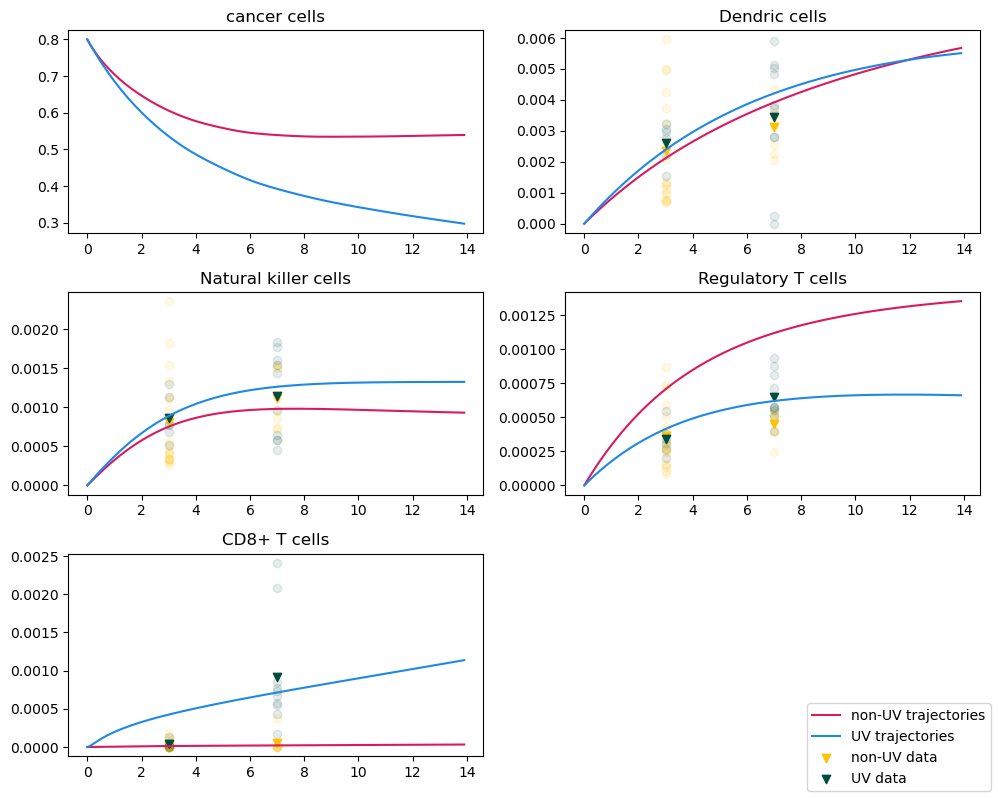

In [92]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)


tspan = (0.0,14.0,)
C_init     = best_params['C_init']
D_init     = best_params['D_init']
N_init     = best_params['N_init']
Tr_init    = best_params['Tr_init']
T8_init    = best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
sol_UV = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (UV_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
t_UV = sol_UV.t
y = sol.y
y_UV = sol_UV.y
import itertools

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.plot(t,y_UV[0],color = c2)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1,label = 'non-UV trajectories')
D_cells.plot(t_UV,y_UV[1],color = c2,label = 'UV trajectories')
D_cells.set_title('Dendric cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1,color = c3)
D_cells.scatter(scatter_UV_times,scatter_UV_Ds,alpha=0.1,color = c4)
D_cells.scatter([3.0,7.0],Ds[:2],alpha=1.0,marker ='v',color = c3,label = 'non-UV data')
D_cells.scatter([3.0,7.0],UV_Ds[:2],alpha=1.0,marker ='v',color = c4,label = 'UV data')

handles = []
labels = []
handles,labels = D_cells.get_legend_handles_labels()
# for handle,label in D_cells.get_legend_handles_labels():
#     handles.append(handle)
#     labels.append(label)
    
NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.plot(t_UV,y_UV[2],color = c2)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1,color = c3)
NK_cells.scatter(scatter_UV_times,scatter_UV_NKs,alpha=0.1,color = c4)
NK_cells.scatter([3,7],NKs[:2],alpha=1.0,marker ='v',color = c3)
NK_cells.scatter([3,7],UV_NKs[:2],alpha=1.0,marker ='v',color = c4)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.plot(t_UV,y_UV[3],color = c2)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1,color = c3)
Treg.scatter(scatter_UV_times,scatter_UV_Tregs,alpha=0.1,color = c4)
Treg.scatter([3,7],Tregs[:2],alpha=1.0,marker ='v',color = c3)
Treg.scatter([3,7],UV_Tregs[:2],alpha=1.0,marker ='v',color = c4)

T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.plot(t_UV,y_UV[4],color = c2)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1,color = c3)
T8.scatter(scatter_UV_times,scatter_UV_T8s,alpha=0.1,color = c4)
T8.scatter([3,7],T8s[:2],alpha=1.0,marker ='v',color = c3)
T8.scatter([3,7],UV_T8s[:2],alpha=1.0,marker ='v',color = c4)


extra_plot = ax[2,1]
extra_plot.set_visible(False)

fig.legend(handles,labels,loc = 'lower right')

plt.tight_layout()
plt.show()

In [12]:
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
# C0 = [0.8,0.0,0.0,0.00,0.0]

tspan = (0.0,50.0,)
import time

In [13]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

TypeError: cancer_ode_parametrised() missing 1 required positional argument: 'p'

In [53]:
from matplotlib import pyplot as plt

NameError: name 'scatter_times' is not defined

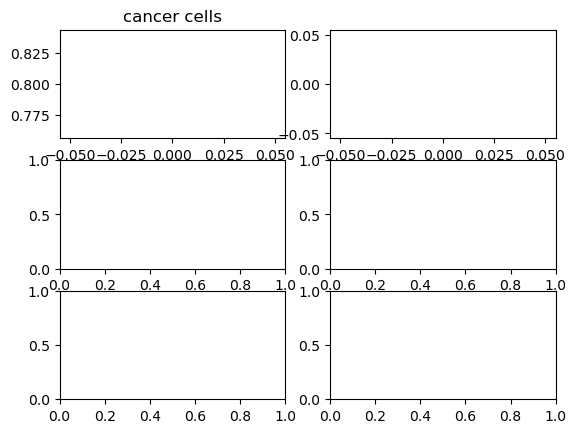

In [108]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],'b')
D_cells.scatter(scatter_times,scatter_Ds,'r')
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)

In [ ]:
param_grid = {
    'eta_8':[328.25]
    'eta_N':[300]
    'D0':[],
    'NK0':[],
    'Treg0':[],
    'T80':[0.0]
}

In [8]:
# parameters we are varying
y_data = np.array(
for param in param_grid:
    sigma_N,lambda_Tr,Tr_0,lambda_T8,T8_0,K_D,K_Tr=parm0 
    def cancer_ode_parametrised(t,y):
        return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
                   D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
                   beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
                  T8_0,K_D,K_Tr)
    tspan = (0.0,200.0,)
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

(5, 10)


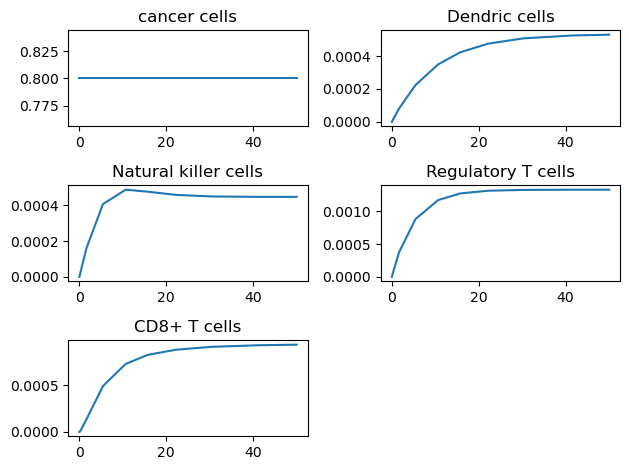

In [106]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

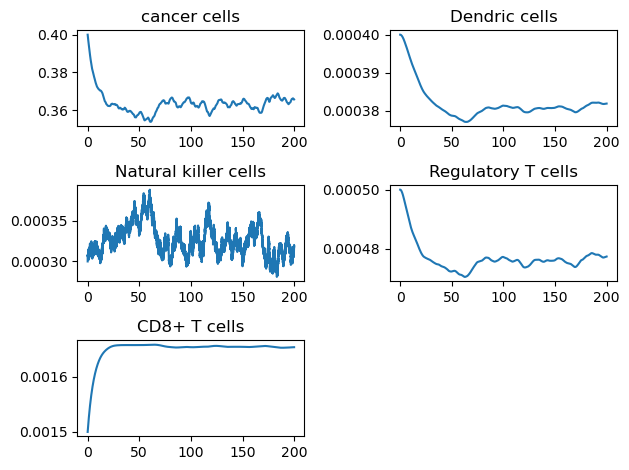

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
